In [6]:
# Базовые библиотеки
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu126
torchvision: 0.25.0+cu126


In [7]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
runs = [] # для runs.csv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [8]:
# Метрики и графики

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
# Датасет CIFAR10
# Трансформации: ToTensor и Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Скачиваем датасет
train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True , transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

100.0%


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000


In [10]:
# Разбиение train/val и DataLoader

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [11]:
# MLP модель

class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 3 * 32 * 32, # 3* из-за rgb
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        #сохранение конфига внутри модели
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.activation = activation
        self.dropout_p = dropout_p
        self.use_batchnorm = use_batchnorm
        self.num_classes = num_classes

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 10])


In [12]:
# Цикл обучения: train/eval + no_grad
# train_one_epoch – обновляет веса;
# evaluate – считает метрики на val/test без градиентов.

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [13]:
# если качество на validation не улучшается `patience` эпох подряд – останавливаемся и возвращаемся к лучшим весам.
# инструмент против переобучения

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [14]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device = device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [15]:
# функция выдающая поле `model_summary` в .csv
def summarize_model(model):
    hidden = "-".join(map(str, model.hidden_dims))
    act = model.activation
    dropout = f"dropout{model.dropout_p}" if model.dropout_p > 0 else "no_dropout"
    bn = "batchnorm" if model.use_batchnorm else "no_bn"
    return hidden, act, dropout, bn
    #return f"{hidden} {act} {dropout} {bn}"

# формирует строку в csv
def make_runs_row(exp_id, model, optimizer, history, dataset="CIFAR10", seed=42):
    opt_params = optimizer.param_groups[0]
    hidden, act, dropout, bn = summarize_model(model)
    return {
        "experiment_id": exp_id,
        "dataset": dataset,
        "seed": seed,

        "model_summary": f"{hidden} {act} {dropout} {bn}",

        "optimizer": type(optimizer).__name__,
        "lr": opt_params.get("lr"),

        "momentum": opt_params.get("momentum", "0"),
        "weight_decay": opt_params.get("weight_decay", 0),

        "epochs_trained": len(history["val_acc"]),
        "best_val_accuracy": float(np.max(history["val_acc"])),
        "best_val_loss": float(np.min(history["val_loss"]))
    }

def get_model_json(model, optimizer, history, dataset="CIFAR10", seed=42):
    opt_params = optimizer.param_groups[0]
    return {
        "dataset": dataset,
        "seed": seed,
        "model": {
            "hidden_dims": "-".join(map(str, model.hidden_dims)),
            "activation": model.activation,
            "dropout": model.dropout_p,
            "batchnorm": model.use_batchnorm,
            "num_classes": model.num_classes
        },
        "training": {
            "optimizer": type(optimizer).__name__,
            "lr": opt_params.get("lr"),
            "epochs": len(history["val_acc"]),
            "best_val_accuracy": float(np.max(history["val_acc"])),
            "best_val_loss": float(np.min(history["val_loss"]))
        }
    }

epoch 01/20 | train loss=1.6617, acc=0.4103 | val loss=1.5502, acc=0.4570
epoch 02/20 | train loss=1.4585, acc=0.4855 | val loss=1.4652, acc=0.4844
epoch 03/20 | train loss=1.3463, acc=0.5249 | val loss=1.4057, acc=0.5141
epoch 04/20 | train loss=1.2627, acc=0.5501 | val loss=1.4704, acc=0.4915
epoch 05/20 | train loss=1.1871, acc=0.5773 | val loss=1.3894, acc=0.5202
epoch 06/20 | train loss=1.1127, acc=0.6056 | val loss=1.4179, acc=0.5172
epoch 07/20 | train loss=1.0515, acc=0.6252 | val loss=1.4270, acc=0.5226
epoch 08/20 | train loss=0.9827, acc=0.6493 | val loss=1.4633, acc=0.5187
epoch 09/20 | train loss=0.9219, acc=0.6717 | val loss=1.5091, acc=0.5217
epoch 10/20 | train loss=0.8655, acc=0.6946 | val loss=1.5189, acc=0.5237
epoch 11/20 | train loss=0.8096, acc=0.7112 | val loss=1.5969, acc=0.5167
epoch 12/20 | train loss=0.7528, acc=0.7304 | val loss=1.6645, acc=0.5168
epoch 13/20 | train loss=0.7050, acc=0.7511 | val loss=1.7124, acc=0.5203
epoch 14/20 | train loss=0.6580, acc=0

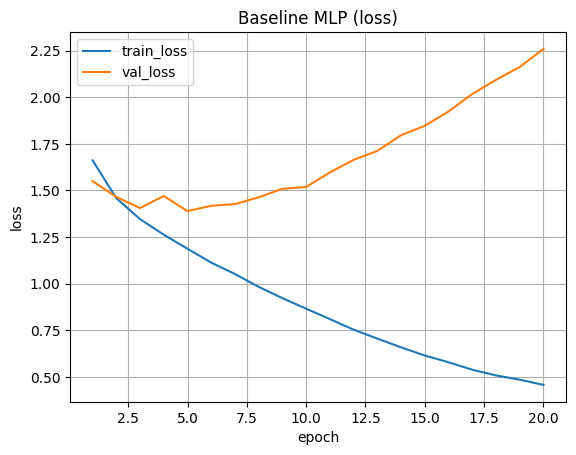

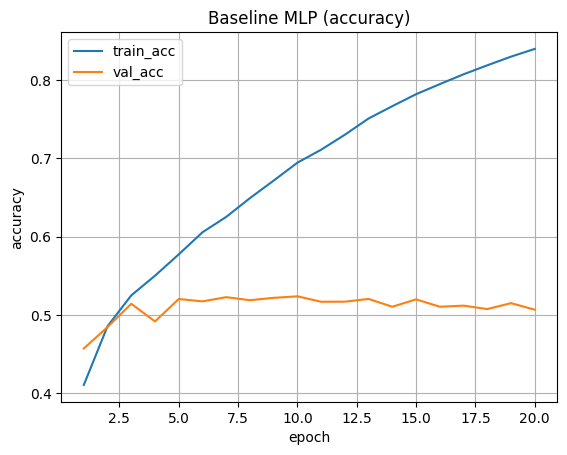

In [16]:
# E1 - Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

runs.append(
    make_runs_row("E1", baseline, optimizer, history_baseline)
)

plot_history(history_baseline, title="Baseline MLP")
# Финальная проверка на test
# test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
# print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.7916, acc=0.3638 | val loss=1.6015, acc=0.4335
epoch 02/20 | train loss=1.6415, acc=0.4203 | val loss=1.5571, acc=0.4522
epoch 03/20 | train loss=1.5830, acc=0.4387 | val loss=1.4980, acc=0.4743
epoch 04/20 | train loss=1.5356, acc=0.4562 | val loss=1.4828, acc=0.4787
epoch 05/20 | train loss=1.5001, acc=0.4703 | val loss=1.4438, acc=0.4863
epoch 06/20 | train loss=1.4632, acc=0.4778 | val loss=1.4368, acc=0.4992
epoch 07/20 | train loss=1.4365, acc=0.4894 | val loss=1.4199, acc=0.5019
epoch 08/20 | train loss=1.4121, acc=0.4974 | val loss=1.4107, acc=0.5044
epoch 09/20 | train loss=1.3930, acc=0.5058 | val loss=1.4019, acc=0.5068
epoch 10/20 | train loss=1.3694, acc=0.5124 | val loss=1.3864, acc=0.5036
epoch 11/20 | train loss=1.3481, acc=0.5198 | val loss=1.3818, acc=0.5104
epoch 12/20 | train loss=1.3284, acc=0.5262 | val loss=1.3796, acc=0.5191
epoch 13/20 | train loss=1.3148, acc=0.5291 | val loss=1.3624, acc=0.5222
epoch 14/20 | train loss=1.2937, acc=0

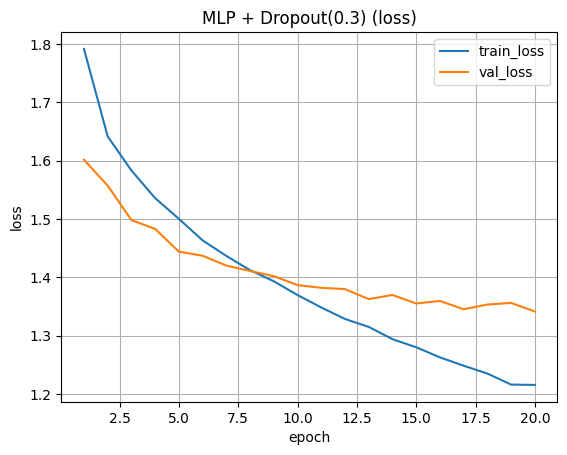

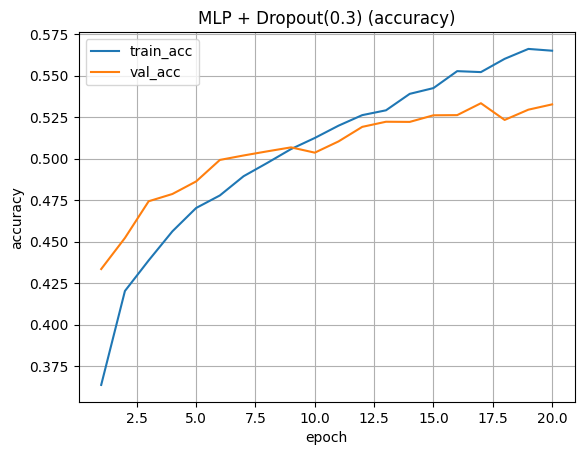

In [17]:
# E2 - Dropout

set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

runs.append(
    make_runs_row("E2", dropout_model, optimizer, history_dropout)
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
# test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
# print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.6347, acc=0.4169 | val loss=1.4949, acc=0.4655
epoch 02/20 | train loss=1.4233, acc=0.4896 | val loss=1.3805, acc=0.5131
epoch 03/20 | train loss=1.3229, acc=0.5292 | val loss=1.3561, acc=0.5208
epoch 04/20 | train loss=1.2490, acc=0.5555 | val loss=1.3526, acc=0.5213
epoch 05/20 | train loss=1.1798, acc=0.5809 | val loss=1.3123, acc=0.5370
epoch 06/20 | train loss=1.1200, acc=0.6015 | val loss=1.3224, acc=0.5416
epoch 07/20 | train loss=1.0640, acc=0.6231 | val loss=1.3339, acc=0.5398
epoch 08/20 | train loss=1.0149, acc=0.6372 | val loss=1.3225, acc=0.5423
epoch 09/20 | train loss=0.9632, acc=0.6578 | val loss=1.3451, acc=0.5446
epoch 10/20 | train loss=0.9130, acc=0.6776 | val loss=1.3463, acc=0.5455
epoch 11/20 | train loss=0.8640, acc=0.6926 | val loss=1.3783, acc=0.5430
epoch 12/20 | train loss=0.8239, acc=0.7091 | val loss=1.4084, acc=0.5421
epoch 13/20 | train loss=0.7832, acc=0.7219 | val loss=1.4250, acc=0.5445
epoch 14/20 | train loss=0.7435, acc=0

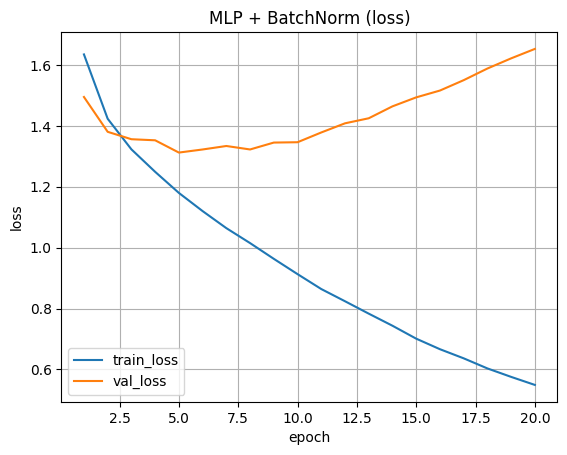

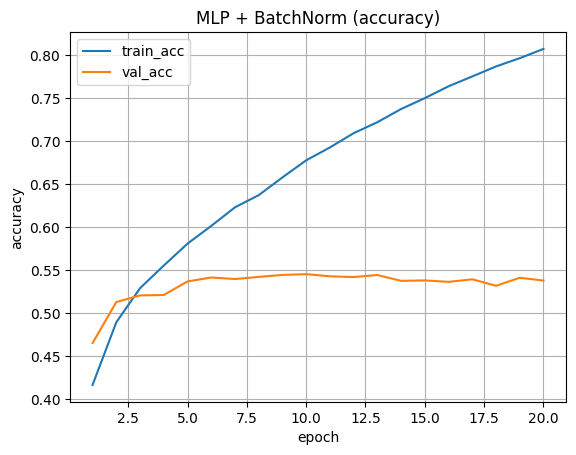

In [18]:
# E3 - BatchNorm

set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

runs.append(
    make_runs_row("E3", bn_model, optimizer, history_bn)
)

plot_history(history_bn, title="MLP + BatchNorm")
# test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
# print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/30 | train loss=1.6347, acc=0.4169 | val loss=1.4949, acc=0.4655
epoch 02/30 | train loss=1.4233, acc=0.4896 | val loss=1.3805, acc=0.5131
epoch 03/30 | train loss=1.3229, acc=0.5292 | val loss=1.3561, acc=0.5208
epoch 04/30 | train loss=1.2490, acc=0.5555 | val loss=1.3526, acc=0.5213
epoch 05/30 | train loss=1.1798, acc=0.5809 | val loss=1.3123, acc=0.5370
epoch 06/30 | train loss=1.1200, acc=0.6015 | val loss=1.3224, acc=0.5416
epoch 07/30 | train loss=1.0640, acc=0.6231 | val loss=1.3339, acc=0.5398
epoch 08/30 | train loss=1.0149, acc=0.6372 | val loss=1.3225, acc=0.5423
epoch 09/30 | train loss=0.9632, acc=0.6578 | val loss=1.3451, acc=0.5446
epoch 10/30 | train loss=0.9130, acc=0.6776 | val loss=1.3463, acc=0.5455
epoch 11/30 | train loss=0.8640, acc=0.6926 | val loss=1.3783, acc=0.5430
epoch 12/30 | train loss=0.8239, acc=0.7091 | val loss=1.4084, acc=0.5421
epoch 13/30 | train loss=0.7832, acc=0.7219 | val loss=1.4250, acc=0.5445
epoch 14/30 | train loss=0.7435, acc=0

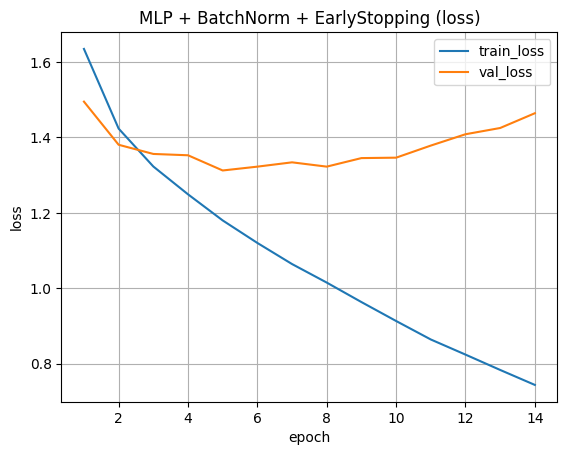

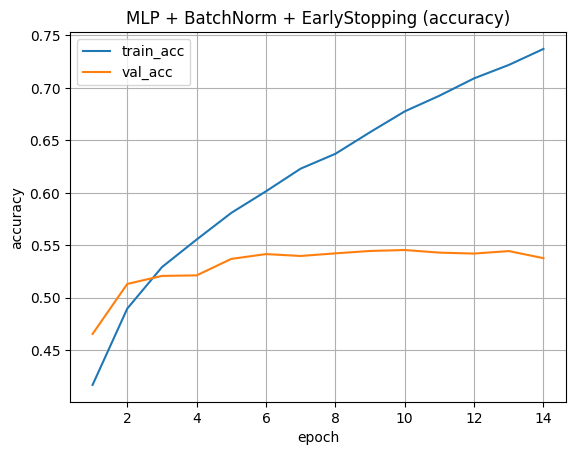

In [19]:
# из E2 и E3 лучшую метрику val_acc показала модель E3 (BatchNorm), используем ее конфиг с easystopping
# E4 - combo: MLP + BatchNorm + EarlyStopping

set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=30, # дадим больше эпох, но остановимся раньше
    early_stopping=es
)

# сохранение runs.csv
runs.append(
    make_runs_row("E4", combo_model, optimizer, history_combo)
)

# сохранение best_model.pt
torch.save(combo_model.state_dict(), os.path.join("./artifacts/", "best_model.pt"))

# сохранение best_config.json
best_config = get_model_json(combo_model, optimizer, history_combo)
with open(os.path.join("./artifacts/", "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

plot_history(history_combo, title="MLP + BatchNorm + EarlyStopping")
# test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
# print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [20]:
# график E4 в png
hist = history_combo
plt.figure(figsize=(8,5))
plt.plot(hist["train_loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Best model training curves (E4)")
plt.legend()

plt.savefig(os.path.join("./artifacts/figures/", "curves_best.png"))
plt.close()

In [21]:
# результаты обучения разных моделей, сравнение по test accurancy

results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.5104
  dropout: test_acc=0.5328
batchnorm: test_acc=0.5296
    combo: test_acc=0.5378


In [22]:
# Часть S09

criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

def make_model():
    # конфиг модели E4
    return MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

# model_E4 = make_model()
# model_E4_opt = make_optimizer(model_E4, kind="adam", lr=1e-3, weight_decay=0.0)

# hist_model_E4 = fit(
#     model_E4, train_loader, val_loader, 
#     model_E4_opt, criterion, device,
#     epochs=EPOCHS,
# )

# plot_history(hist_model_E4, title="Model E4: Adam lr=1e-3")


Experiment LR_high: Adam lr=0.1
epoch 01/6 | train loss=1.8859, acc=0.3129 | val loss=1.7077, acc=0.3854
epoch 02/6 | train loss=1.7027, acc=0.3857 | val loss=1.6230, acc=0.4147
epoch 03/6 | train loss=1.6142, acc=0.4184 | val loss=1.5860, acc=0.4277
epoch 04/6 | train loss=1.5556, acc=0.4396 | val loss=1.5337, acc=0.4528
epoch 05/6 | train loss=1.5237, acc=0.4506 | val loss=1.5162, acc=0.4620
epoch 06/6 | train loss=1.4905, acc=0.4666 | val loss=1.5568, acc=0.4490


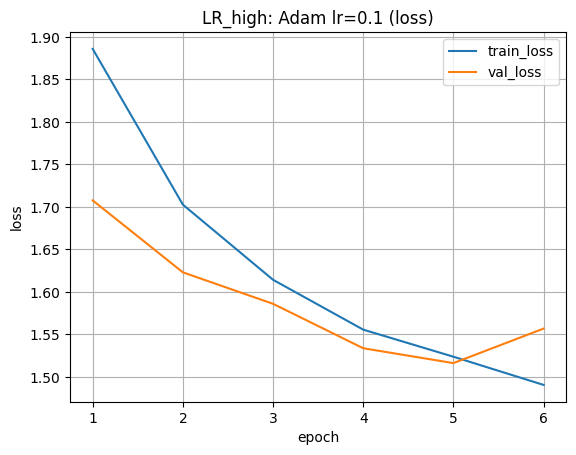

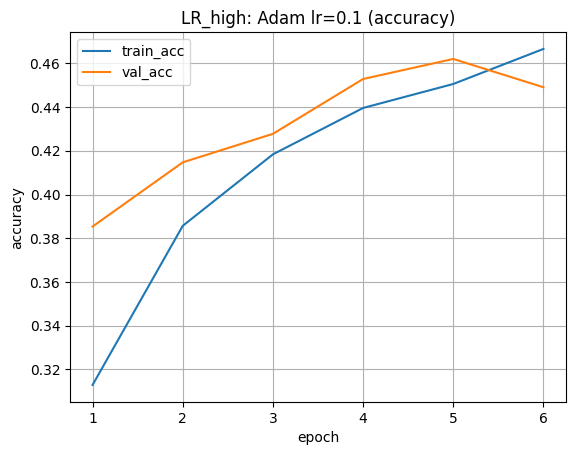


Experiment LR_low: Adam lr=1e-05
epoch 01/6 | train loss=1.9959, acc=0.3014 | val loss=1.8459, acc=0.3761
epoch 02/6 | train loss=1.7960, acc=0.3971 | val loss=1.7477, acc=0.4195
epoch 03/6 | train loss=1.7116, acc=0.4325 | val loss=1.6874, acc=0.4378
epoch 04/6 | train loss=1.6520, acc=0.4517 | val loss=1.6425, acc=0.4533
epoch 05/6 | train loss=1.6025, acc=0.4694 | val loss=1.6025, acc=0.4660
epoch 06/6 | train loss=1.5612, acc=0.4840 | val loss=1.5734, acc=0.4730


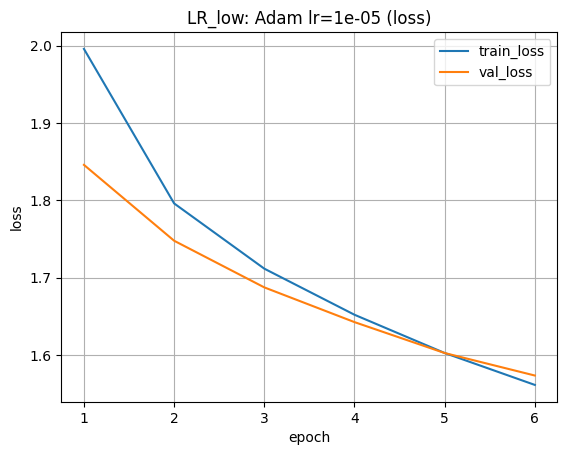

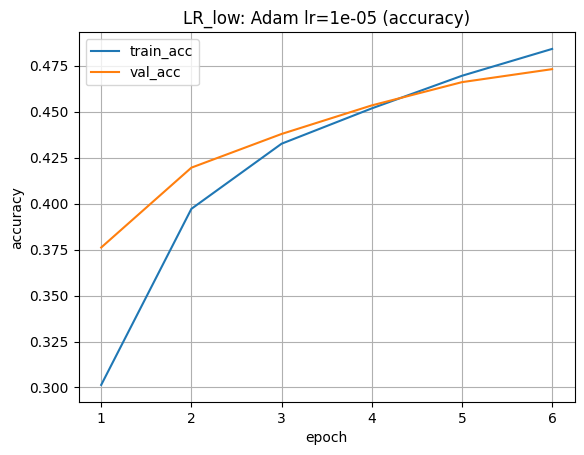

In [23]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("O1", "LR_high", 1e-1),
    ("O2", "LR_low",  1e-5),
]

results = []
for exp_id, name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=exp_id, optimizer_kind="adam", lr=lr)
    results.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")

In [24]:
# графики O1 и O2 в один png
plt.figure(figsize=(10,5))
for r in results:
    if r["exp_id"] in ["O1", "O2"]:

        plt.plot(
            r["history"]["val_loss"],
            label=f'{r["exp_id"]} (lr={r["lr"]})'
        )
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Learning rate extremes")
plt.legend()
plt.savefig(os.path.join("./artifacts/figures/", "curves_lr_extremes.png"))
plt.close()

Experiment SGD+momentum+weight decay: SGD lr=0.1 momentum=0.9, wd=1e-4
epoch 01/15 | train loss=1.6902, acc=0.3942 | val loss=1.5068, acc=0.4622
epoch 02/15 | train loss=1.4769, acc=0.4723 | val loss=1.4305, acc=0.4887
epoch 03/15 | train loss=1.3869, acc=0.5023 | val loss=1.3838, acc=0.5095
epoch 04/15 | train loss=1.3227, acc=0.5272 | val loss=1.3900, acc=0.5062
epoch 05/15 | train loss=1.2761, acc=0.5433 | val loss=1.3987, acc=0.5119
epoch 06/15 | train loss=1.2282, acc=0.5597 | val loss=1.3537, acc=0.5244
epoch 07/15 | train loss=1.1909, acc=0.5716 | val loss=1.3792, acc=0.5141
epoch 08/15 | train loss=1.1609, acc=0.5849 | val loss=1.4292, acc=0.5087
epoch 09/15 | train loss=1.1322, acc=0.5964 | val loss=1.3489, acc=0.5371
epoch 10/15 | train loss=1.1058, acc=0.6032 | val loss=1.3969, acc=0.5318
epoch 11/15 | train loss=1.0803, acc=0.6142 | val loss=1.3712, acc=0.5240
epoch 12/15 | train loss=1.0541, acc=0.6212 | val loss=1.4006, acc=0.5333
epoch 13/15 | train loss=1.0301, acc=0.62

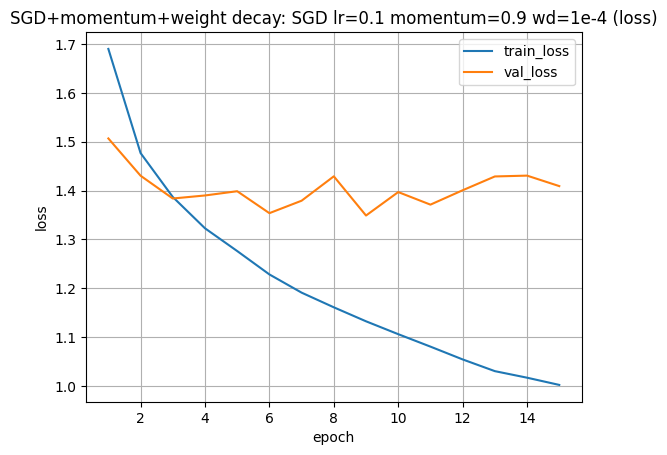

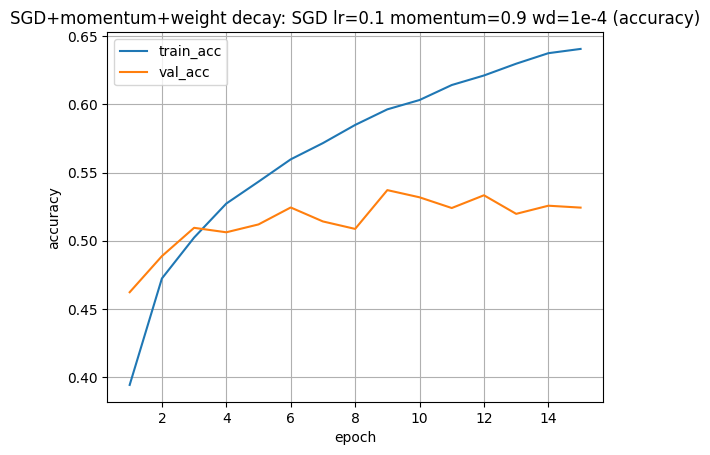

In [25]:
# SGD+momentum
print("Experiment SGD+momentum+weight decay: SGD lr=0.1 momentum=0.9, wd=1e-4")
res = run_experiment(exp_id="O3", optimizer_kind="sgd", lr=0.1, momentum=0.9, weight_decay=1e-4, epochs=15)
results.append(res)
plot_history(res["history"], title="SGD+momentum+weight decay: SGD lr=0.1 momentum=0.9 wd=1e-4")

In [26]:
rows = []
for r in results:
    res = {
        "experiment_id": r["exp_id"],
        "dataset": "CIFAR10",
        "seed": 42,
        "model_summary": "256-128 relu batchnorm",
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"] if r["momentum"] else "0",
        "weight_decay": r["weight_decay"],
        "epochs_trained": r["epochs_ran"],
        "best_val_accuracy": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"]
    }
    runs.append(res)
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_lr = pd.DataFrame(rows)#.sort_values()(by="best_val_acc", ascending=False)
display(df_lr)

df_runs = pd.DataFrame(runs)
csv_path = os.path.join("./artifacts/", "runs.csv")
df_runs.to_csv(csv_path, index=False)

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,O1,adam,0.10000,0.0000,6,0.461982,1.516209
1,O2,adam,0.00001,0.0000,6,0.473029,1.573358
2,O3,sgd,0.10000,0.0001,15,0.537122,1.348893
